# NBA Player Profiles: Understanding Different Types of NBA Players Through Data

A beginner data science portfolio project analyzing NBA player statistics from the **2024-25 regular season**.

**Goal:** Build simple, transparent statistical profiles for NBA players and use them to answer questions like:
- What makes different players statistically unique?
- Who are the scorers, playmakers, rebounders, and all-around players?
- Which players are efficient relative to their scoring volume?
- Which stats tend to move together?

No machine learning is used here -- every result comes from pandas, basic math, and simple rules that are easy to explain.

## Step 1: Load and Understand the Data

**What we're doing:** Before we clean or analyze anything, we need to load the dataset and get a feel for it -- how big it is, what columns it has, whether anything is missing, and what a "typical" row looks like. This is normal for every real data science project: you never start analyzing a dataset you haven't looked at first.

The data was pulled once from the NBA's stats API (`nba_api`) using `data/fetch_data.py` and saved as a CSV in `data/`. From here on, we just read that CSV -- no internet connection needed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw CSV into a pandas DataFrame -- think of a DataFrame as an
# in-memory spreadsheet: rows are players, columns are stats.
df = pd.read_csv("../data/nba_player_stats_2024_25.csv")

df.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,POSITION
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,24.0,26,14,12,0.538,...,247,207,219,300,292,159,44,281,1,G
1,1631260,AJ Green,AJ,1610612749,MIL,25.0,73,44,29,0.603,...,136,394,278,83,342,281,44,318,1,G
2,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,29,8,21,0.276,...,239,321,273,522,332,281,44,328,2,G
3,203932,Aaron Gordon,Aaron,1610612743,DEN,29.0,51,33,18,0.647,...,277,89,98,26,127,134,44,124,1,F
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,28.0,62,39,23,0.629,...,413,350,363,142,422,281,44,403,1,G


**What this code does:**
- `pd.read_csv(...)` reads the CSV file off disk into a DataFrame called `df`.
- `df.head()` shows the first 5 rows so we can eyeball the data.

**Expected output:** A table where each row is one player-season and columns include things like `PLAYER_NAME`, `TEAM_ABBREVIATION`, `GP`, `MIN`, `PTS`, `AST`, `REB`, `FG_PCT`, and more (68 columns total -- this raw pull includes some columns we won't need, like fantasy points and per-stat rankings).

**How to interpret it:** This is just a first look. Don't worry about every column yet -- in Step 2 (cleaning) we'll narrow this down to the columns we actually care about.

In [2]:
# .shape tells us (number of rows, number of columns)
df.shape

(569, 68)

**Expected output:** Something like `(569, 68)` -- 569 players, 68 columns (67 original stat columns plus the `POSITION` column we merged in ourselves).

**How to interpret it:** This confirms the dataset is one row per player for the season, and gives us a sense of scale -- small enough to explore easily in pandas, no need for any big-data tools.

In [3]:
# .info() lists every column, how many non-missing values it has,
# and its data type (e.g. int64, float64, object/text)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 68 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              569 non-null    int64  
 1   PLAYER_NAME            569 non-null    object 
 2   NICKNAME               569 non-null    object 
 3   TEAM_ID                569 non-null    int64  
 4   TEAM_ABBREVIATION      569 non-null    object 
 5   AGE                    569 non-null    float64
 6   GP                     569 non-null    int64  
 7   W                      569 non-null    int64  
 8   L                      569 non-null    int64  
 9   W_PCT                  569 non-null    float64
 10  MIN                    569 non-null    float64
 11  FGM                    569 non-null    float64
 12  FGA                    569 non-null    float64
 13  FG_PCT                 569 non-null    float64
 14  FG3M                   569 non-null    float64
 15  FG3A  

**Expected output:** A list of all 68 columns. Most stat columns (`GP`, `MIN`, `PTS`, `FG_PCT`, etc.) should be numeric (`int64` or `float64`). `PLAYER_NAME`, `TEAM_ABBREVIATION`, and `POSITION` should be text (`object`). You should also see that `POSITION` has fewer non-null values than the other columns.

**How to interpret it:** This tells us two important things before we clean:
1. The numeric columns are already numeric (good -- the API gave us clean types, unlike a scraped CSV where numbers sometimes come in as text).
2. `POSITION` has missing values, which we already expected -- some players had short stints and weren't on a team's official roster snapshot we used. We'll decide how to handle that in Step 2 (Cleaning).

In [4]:
# .isna() marks every missing (NaN) value as True/False, and .sum()
# adds those up per column, so we get a count of missing values per column
missing_counts = df.isna().sum()

# Only show columns that actually have at least one missing value
missing_counts[missing_counts > 0]

POSITION    41
dtype: int64

**Expected output:** `POSITION` with around 41 missing values, and possibly `FG3_PCT` or `FT_PCT` with a handful of missing values (this happens when a player attempted 0 three-pointers or 0 free throws all season -- a percentage of zero attempts is undefined, so the API leaves it blank rather than showing a misleading 0%).

**How to interpret it:** Missing values aren't automatically "bad data" -- here they have real basketball explanations. Knowing *why* a value is missing tells us how to handle it (fill it, drop it, or leave it) in the cleaning step, instead of blindly dropping every row with any missing value.

In [5]:
# A "duplicate" row would mean the exact same player-season appears twice.
# .duplicated() flags repeated rows as True; .sum() counts how many there are.
df.duplicated().sum()

np.int64(0)

**Expected output:** `0`.

**How to interpret it:** No exact duplicate rows -- makes sense, since each row comes from a unique `PLAYER_ID` in the API. We still check this explicitly rather than assuming it, because it's a one-line safeguard against a messier dataset silently double-counting a player.

In [6]:
# .describe() gives quick summary statistics (count, mean, std, min,
# 25/50/75th percentiles, max) for every numeric column
df[["GP", "MIN", "PTS", "AST", "REB", "STL", "BLK", "TOV", "FG_PCT", "FG3_PCT", "FT_PCT"]].describe()

,GP,MIN,PTS,AST,REB,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT
count,569.000000,569.000000,569.00000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,46.231986,19.428998,8.88717,2.085237,3.595606,0.668717,0.402988,1.089455,0.446109,0.299025,0.720241
std,24.357135,9.539740,6.56826,1.819464,2.422532,0.421147,0.405605,0.829386,0.114639,0.137758,0.200426
min,1.000000,0.900000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,11.800000,4.00000,0.800000,1.800000,0.400000,0.100000,0.500000,0.406000,0.267000,0.679000
50%,50.000000,19.500000,7.20000,1.500000,3.200000,0.600000,0.300000,0.900000,0.448000,0.338000,0.763000
75%,68.000000,27.200000,12.10000,2.700000,4.800000,0.900000,0.500000,1.500000,0.496000,0.377000,0.829000
max,82.000000,37.700000,32.70000,11.600000,13.900000,3.000000,3.800000,4.700000,1.000000,1.000000,1.000000


**Expected output:** A table of stats-about-stats. For example, `PTS` (points per game) might show a mean around 8-9 and a max around 32-33 (an MVP-caliber scorer), with `min` at or near 0 (a player who barely scored in limited minutes).

**How to interpret it:** This is our first real signal about the shape of the data:
- A big gap between the `mean` and `max` for `PTS`, `AST`, `REB` tells us scoring/playmaking/rebounding is concentrated in a small group of star players -- most players contribute modestly.
- `GP` (games played) having a low `min` (maybe 1-2 games) tells us the dataset includes players who barely played all season. That's useful context for Step 2, where we'll decide whether to filter these low-sample players out before doing per-game comparisons (a player who played 1 game and scored 20 points isn't really a "20 PPG scorer").

## Step 2: Clean the Data

**What we're doing:** Step 1 showed us three things to deal with:
1. We only need a handful of the 68 columns.
2. `POSITION` is missing for 41 players.
3. Some players played very few games/minutes, which makes their per-game stats unreliable ("noisy small samples").

We'll fix each one, explaining *why* along the way -- cleaning decisions should always have a reason, not just "because that's what you do."


In [7]:
# Keep only the columns we actually need for this project, and give them
# friendlier names. Renaming now means every later step (charts, functions,
# the README) can use simple names like PPG/APG instead of PTS/AST.
columns_to_keep = {
    "PLAYER_NAME": "PLAYER",
    "TEAM_ABBREVIATION": "TEAM",
    "POSITION": "POSITION",
    "GP": "GP",
    "MIN": "MIN",
    "PTS": "PPG",
    "AST": "APG",
    "REB": "RPG",
    "STL": "SPG",
    "BLK": "BPG",
    "TOV": "TOV",
    "FG_PCT": "FG_PCT",
    "FG3_PCT": "FG3_PCT",
    "FT_PCT": "FT_PCT",
}

df_clean = df[list(columns_to_keep.keys())].rename(columns=columns_to_keep)
df_clean.head()

,PLAYER,TEAM,POSITION,GP,MIN,PPG,APG,RPG,SPG,BPG,TOV,FG_PCT,FG3_PCT,FT_PCT
0,A.J. Lawson,TOR,G,26,18.7,9.1,1.2,3.3,0.5,0.2,0.6,0.421,0.327,0.683
1,AJ Green,MIL,G,73,22.7,7.4,1.5,2.4,0.5,0.1,0.5,0.429,0.427,0.815
2,AJ Johnson,WAS,G,29,22.0,7.6,2.6,2.0,0.4,0.1,1.2,0.385,0.267,0.865
3,Aaron Gordon,DEN,F,51,28.4,14.7,3.2,4.8,0.5,0.3,1.4,0.531,0.436,0.810
4,Aaron Holiday,HOU,G,62,12.8,5.5,1.3,1.3,0.3,0.2,0.6,0.437,0.398,0.829


**What this code does:**
- `columns_to_keep` is a dictionary mapping *old column name* -> *new column name*.
- `df[list(columns_to_keep.keys())]` selects just those columns, dropping the other ~54 columns we don't need (fantasy points, per-stat rankings, win/loss counts, etc.).
- `.rename(columns=columns_to_keep)` renames them in one step.

**Expected output:** A much narrower table -- 14 columns instead of 68 -- with names like `PPG`, `APG`, `RPG` that read naturally.

**Why do this:** Fewer, clearly-named columns make every later step (charts, the player profile function, the README) easier to read and less error-prone. We're not losing information we plan to use -- we deliberately chose this column list to match what a "player profile" needs.

In [8]:
# Confirm the numeric columns actually are numeric (not text).
# We already saw this in Step 1's df.info(), but re-checking on df_clean
# after selecting columns is a cheap sanity check before we do any math on them.
df_clean.dtypes

PLAYER       object
TEAM         object
POSITION     object
GP            int64
MIN         float64
PPG         float64
APG         float64
RPG         float64
SPG         float64
BPG         float64
TOV         float64
FG_PCT      float64
FG3_PCT     float64
FT_PCT      float64
dtype: object

**Expected output:** `PLAYER`, `TEAM`, `POSITION` as `object` (text); everything else (`GP`, `MIN`, `PPG`, `APG`, `RPG`, `SPG`, `BPG`, `TOV`, `FG_PCT`, `FG3_PCT`, `FT_PCT`) as `int64` or `float64`.

**Why we're not doing a manual conversion here:** Some NBA CSVs you'd download (e.g. scraped from a webpage) store numbers as text with stray characters, which would need `pd.to_numeric()` to fix. Because we pulled this data from an API that returns proper JSON types, pandas already parsed these columns as numbers -- there's nothing to convert. It's still worth checking rather than assuming.

### Handling the missing `POSITION` values

41 players have no `POSITION` value, because they weren't on a team's final-season roster snapshot (the endpoint we used for positions) even though they have real game stats.

**Options considered:**
- *Drop these 41 rows* -- simplest, but throws away real scoring/rebounding/assist data just because one unrelated column is missing. Not worth it.
- *Look up each player's position individually* -- more accurate, but adds real complexity (extra API calls per player) for a beginner project where position is a nice-to-have, not central to the analysis.
- *Fill with a placeholder label* -- keeps every player's stats usable, and clearly marks what we don't know.

We'll go with the third option.

In [9]:
# .fillna(value) replaces every missing value in a column with `value`.
# "UNK" (unknown) makes it obvious this isn't a real position, so it won't
# get confused with an actual "C" or "G" later when we group by position.
df_clean["POSITION"] = df_clean["POSITION"].fillna("UNK")

df_clean["POSITION"].isna().sum()  # should be 0 now

np.int64(0)

**Expected output:** `0` -- no more missing values in `POSITION`.

**How to interpret it:** We haven't invented information we don't have; we've just labeled the gap honestly. Any analysis that groups by position (e.g. "average rebounds by position") will show a small "UNK" group, which is an accurate reflection of the data rather than a hidden error.

### Filtering out extremely low-sample players

Step 1's `describe()` showed `GP` (games played) ranging from 1 to a full season, and `MIN` (minutes per game) with a 25th percentile around 11.8. A player who appeared in 2 games or averaged 3 minutes doesn't have a statistically meaningful "profile" yet -- one hot or cold game can swing their per-game numbers wildly.

**Decision:** Keep only players with **at least 20 games played** and **at least 10 minutes per game**. This is a judgment call, not an official rule -- it's a common-sense cutoff that removes short call-ups, injury-shortened seasons, and garbage-time-only players, while keeping essentially every player who had a real rotation role.

In [10]:
before = len(df_clean)

df_clean = df_clean[(df_clean["GP"] >= 20) & (df_clean["MIN"] >= 10)].reset_index(drop=True)

after = len(df_clean)
print(f"Removed {before - after} low-sample players ({before} -> {after})")

Removed 158 low-sample players (569 -> 411)


**Expected output:** Something like `Removed 158 low-sample players (569 -> 411)`.

**How to interpret it:** We kept about 72% of players -- everyone with a real, sustained role on their team. This trade-off matters: we're now analyzing "rotation-or-better NBA players," not "everyone who appeared in an NBA box score." That's the right population for questions like "who are the best scorers/passers/rebounders," since we want per-game stats that reflect a real role, not a small-sample fluke.

`.reset_index(drop=True)` just renumbers the rows 0, 1, 2, ... after we removed some -- purely cosmetic, so the row index stays clean.

In [11]:
# Defensive check: confirm there are still no duplicate rows after cleaning.
print("Duplicate rows:", df_clean.duplicated().sum())

# Save the cleaned dataset so later notebook sections (and anyone re-running
# this project) can skip straight to a ready-to-use file.
df_clean.to_csv("../data/nba_player_stats_2024_25_clean.csv", index=False)

df_clean.shape

Duplicate rows: 0


(411, 14)

**Expected output:** `Duplicate rows: 0`, and a shape of about `(411, 14)`.

**How to interpret it:** `df_clean` is now our working dataset for the rest of the project: 14 clearly-named columns, no missing values, no duplicates, and restricted to players with a real season-long role. Everything from here on (EDA, feature engineering, archetypes, the player profile function) builds on this cleaned table.

## Step 3: Exploratory Data Analysis (EDA)

**What we're doing:** Now that `df_clean` is trustworthy, we can start asking real questions of it. Each chart below is built to answer one specific question -- not just "because charts are nice." We'll use `df_clean.sort_values()` to find leaders, `.plot(kind="barh")` for rankings, `.plot(kind="scatter")` for relationships, and a correlation heatmap for how stats move together.

Charts get saved into `outputs/charts/` as we go, so they can be dropped straight into the README later.

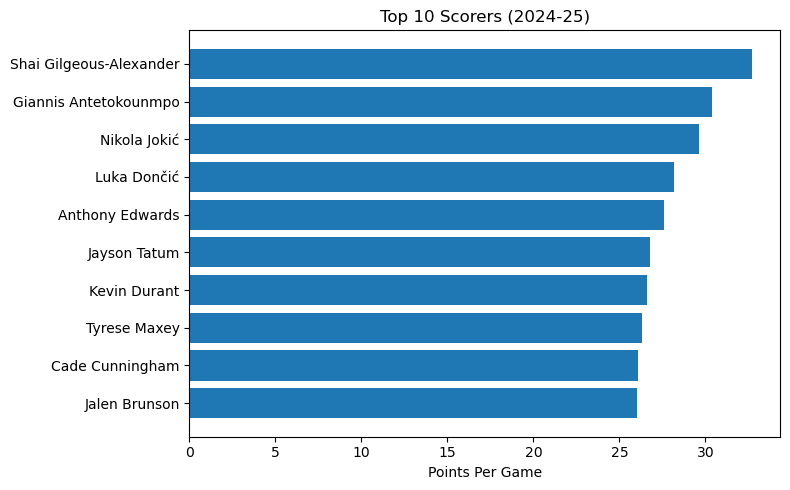

In [12]:
top_scorers = df_clean.sort_values("PPG", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_scorers["PLAYER"], top_scorers["PPG"], color="#1f77b4")
plt.xlabel("Points Per Game")
plt.title("Top 10 Scorers (2024-25)")
plt.gca().invert_yaxis()  # highest scorer at the top of the chart
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_scorers.png", dpi=150)
plt.show()

**What this code does:**
- `sort_values("PPG", ascending=False).head(10)` finds the 10 highest scorers.
- `plt.barh(...)` draws a horizontal bar chart -- easier to read player names on than a vertical bar chart.
- `invert_yaxis()` flips the order so the #1 scorer appears at the top instead of the bottom.

**Expected output:** A horizontal bar chart with the league's top 10 scorers, topped by whoever led the league in PPG that season.

**How to interpret it:** This answers "who were the primary scoring options in the league?" It's also a sanity check -- these should be recognizable star names, which confirms our cleaning didn't accidentally corrupt the data.

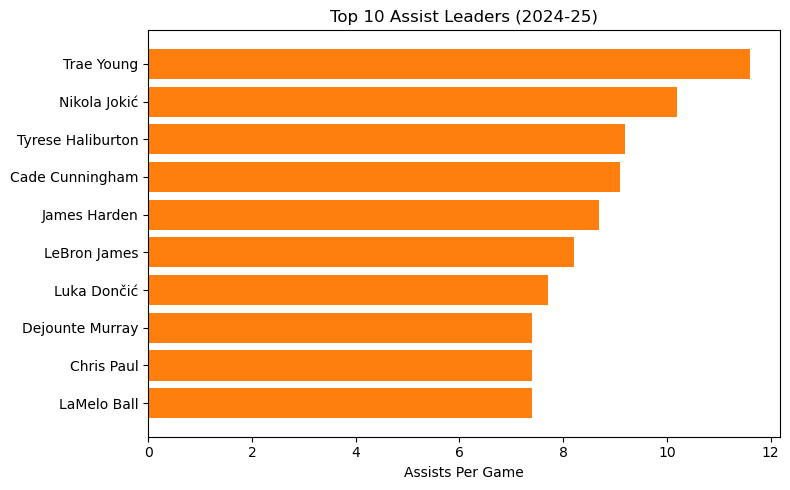

In [13]:
top_assists = df_clean.sort_values("APG", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_assists["PLAYER"], top_assists["APG"], color="#ff7f0e")
plt.xlabel("Assists Per Game")
plt.title("Top 10 Assist Leaders (2024-25)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_assists.png", dpi=150)
plt.show()

**Expected output:** A bar chart led by the league's top playmakers (typically starting point guards).

**How to interpret it:** This is our first look at *playmaking* as separate from scoring -- notice this list is a different set of players than the scoring list. That's an early hint that "scorer" and "playmaker" are different player types, which we'll formalize in Step 5 (archetypes).

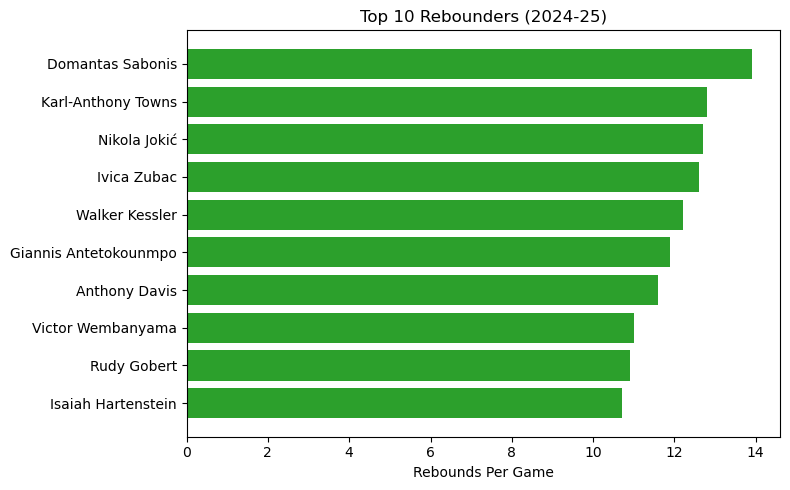

In [14]:
top_rebounders = df_clean.sort_values("RPG", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_rebounders["PLAYER"], top_rebounders["RPG"], color="#2ca02c")
plt.xlabel("Rebounds Per Game")
plt.title("Top 10 Rebounders (2024-25)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_rebounders.png", dpi=150)
plt.show()

**Expected output:** A bar chart dominated by centers and power forwards.

**How to interpret it:** Rebounding leaders should skew toward taller, interior positions. If we later check the `POSITION` column for this group, we'd expect mostly "C" and "F" -- a good consistency check between two different columns in our dataset.

### Most efficient high-volume scorers

Scoring a lot and scoring *efficiently* are different skills. A player who scores 15 points a game on great shooting percentages is doing something different than one who needs a lot of shots to get there. We don't have shot-attempt data in our trimmed columns, so we'll use `FG_PCT` (field goal percentage) as our efficiency measure.

**Definition for this project:** "high-volume scorer" = at least 15 PPG (roughly the top quarter of scorers in our cleaned dataset). Among those, we rank by `FG_PCT` to find who scores a lot *and* shoots a high percentage.

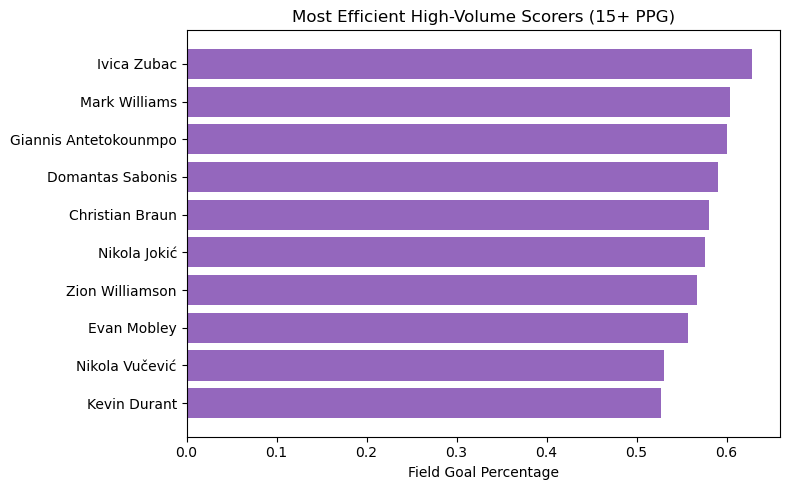

,PLAYER,TEAM,PPG,FG_PCT
152,Ivica Zubac,LAC,16.8,0.628
278,Mark Williams,CHA,15.3,0.604
136,Giannis Antetokounmpo,MIL,30.4,0.601
112,Domantas Sabonis,SAC,19.1,0.590
66,Christian Braun,DEN,15.4,0.580
306,Nikola Jokić,DEN,29.6,0.576
410,Zion Williamson,NOP,24.6,0.567
126,Evan Mobley,CLE,18.5,0.557
308,Nikola Vučević,CHI,18.5,0.530
244,Kevin Durant,PHX,26.6,0.527


In [15]:
high_volume = df_clean[df_clean["PPG"] >= 15]
efficient_scorers = high_volume.sort_values("FG_PCT", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(efficient_scorers["PLAYER"], efficient_scorers["FG_PCT"], color="#9467bd")
plt.xlabel("Field Goal Percentage")
plt.title("Most Efficient High-Volume Scorers (15+ PPG)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/charts/efficient_high_volume_scorers.png", dpi=150)
plt.show()

efficient_scorers[["PLAYER", "TEAM", "PPG", "FG_PCT"]]

**Expected output:** A bar chart and table of players averaging 15+ points while also posting a high field goal percentage -- typically centers/forwards who score efficiently near the basket, since 3-point shooters naturally have lower `FG_PCT` even when they're effective scorers.

**How to interpret it:** This is a real limitation worth calling out: `FG_PCT` favors players who shoot mostly 2-pointers over 3-point shooters, because it doesn't weight makes by shot value. A player like a high-volume 3-point shooter can be very efficient in actual scoring value while showing a lower `FG_PCT` than a center. We're keeping this simple on purpose -- a more complete efficiency stat (true shooting %) would need shot-attempt data we didn't pull in.

### Relationship between minutes and points

**Question:** Do players who play more minutes simply score more, or is scoring more about role/skill than playing time?

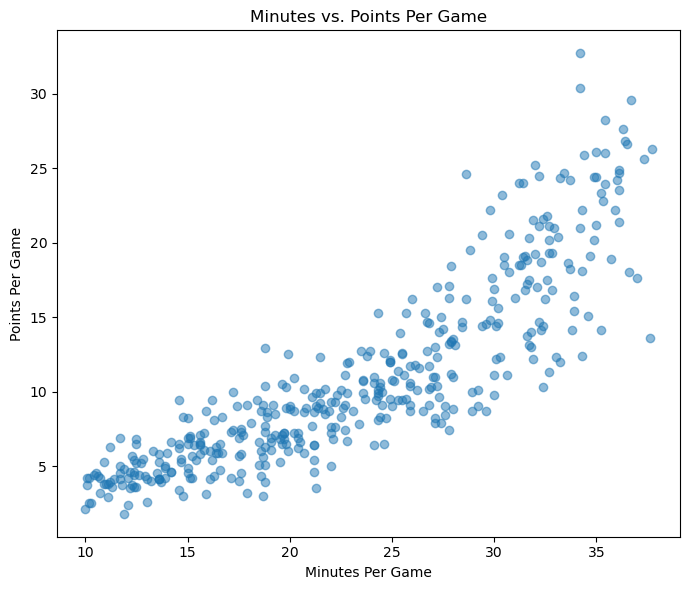

,MIN,PPG
MIN,1.000000,0.867373
PPG,0.867373,1.000000


In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(df_clean["MIN"], df_clean["PPG"], alpha=0.5, color="#1f77b4")
plt.xlabel("Minutes Per Game")
plt.ylabel("Points Per Game")
plt.title("Minutes vs. Points Per Game")
plt.tight_layout()
plt.savefig("../outputs/charts/minutes_vs_points.png", dpi=150)
plt.show()

df_clean[["MIN", "PPG"]].corr()

**What this code does:** `plt.scatter()` plots one dot per player -- `MIN` on the x-axis, `PPG` on the y-axis. `alpha=0.5` makes dots semi-transparent so overlapping players are visible as darker patches. `.corr()` computes the Pearson correlation coefficient between the two columns (a number from -1 to 1).

**Expected output:** A clear upward-sloping cloud of points, and a correlation around **0.85-0.9**.

**How to interpret it:** A strong positive correlation makes basketball sense -- coaches give more minutes to players who produce, and players who play more minutes get more scoring opportunities. It's not a perfect 1.0, though: some players play a lot of minutes for defense/playmaking without scoring much (low PPG, high MIN), and some bench scorers are efficient in short bursts (higher PPG per minute than their minutes alone would suggest). That gap is exactly what a stat like points-per-36-minutes (Step 4) is designed to reveal.

### Relationship between assists and turnovers

**Question:** Do players who create more assists also commit more turnovers, since ball-handling and playmaking naturally come with more risk?

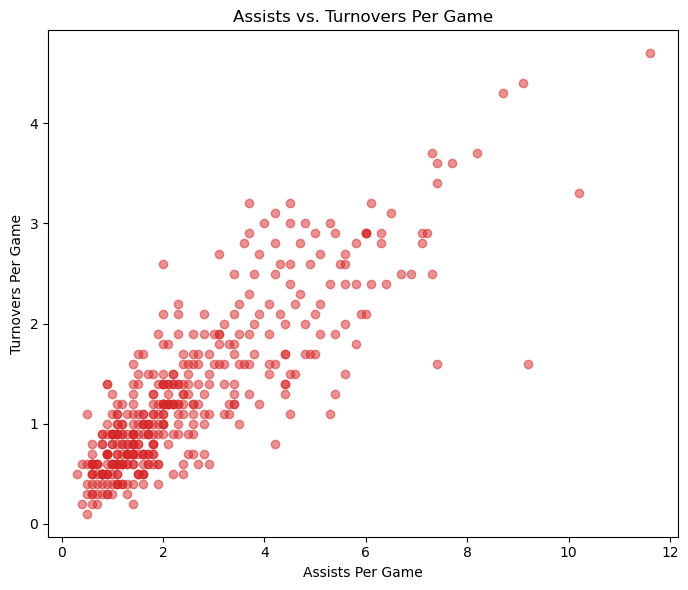

,APG,TOV
APG,1.00000,0.84844
TOV,0.84844,1.00000


In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(df_clean["APG"], df_clean["TOV"], alpha=0.5, color="#d62728")
plt.xlabel("Assists Per Game")
plt.ylabel("Turnovers Per Game")
plt.title("Assists vs. Turnovers Per Game")
plt.tight_layout()
plt.savefig("../outputs/charts/assists_vs_turnovers.png", dpi=150)
plt.show()

df_clean[["APG", "TOV"]].corr()

**Expected output:** Another clear upward trend, with a correlation likely around **0.7-0.85** -- even stronger than minutes-vs-points.

**How to interpret it:** This makes sense: players who handle the ball more (to generate assists) also have more opportunities to turn it over. A high correlation here means raw turnover totals alone are a poor way to judge a player's ball security -- a point guard averaging 8 assists and 3 turnovers is being far more careful with the ball than a bench player averaging 1 assist and 1.5 turnovers, even though the second player's turnover *count* is lower. This is a good example of why context (assists relative to turnovers) matters more than a single raw number.

### Correlations between major player statistics

**Question:** Beyond the two pairs we just checked individually, which stats tend to move together across *all* players, and which are independent of each other?

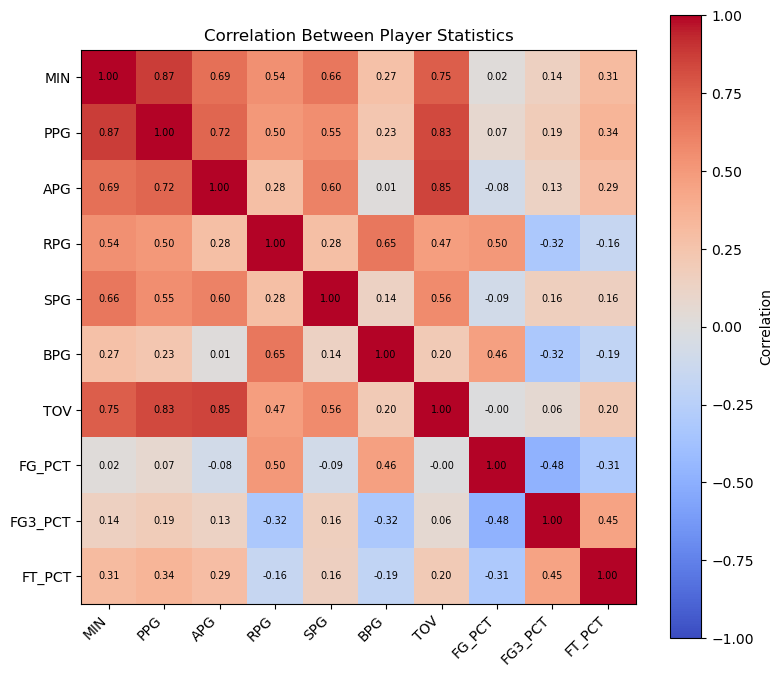

In [18]:
stat_cols = ["MIN", "PPG", "APG", "RPG", "SPG", "BPG", "TOV", "FG_PCT", "FG3_PCT", "FT_PCT"]
corr_matrix = df_clean[stat_cols].corr()

plt.figure(figsize=(8, 7))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(stat_cols)), stat_cols, rotation=45, ha="right")
plt.yticks(range(len(stat_cols)), stat_cols)
plt.title("Correlation Between Player Statistics")

# Write the correlation number inside each cell so exact values are readable
for i in range(len(stat_cols)):
    for j in range(len(stat_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png", dpi=150)
plt.show()

**What this code does:** `df_clean[stat_cols].corr()` computes the correlation between every pair of the listed stats at once, producing a 10x10 table. `plt.imshow()` colors each cell by its correlation value (red = strong positive, blue = strong negative, white = no relationship), and the loop at the bottom stamps the exact number onto each cell.

**Expected output:** A symmetric grid (diagonal = 1.00, since every stat perfectly correlates with itself). You should see strong red cells for `MIN`-`PPG`, `APG`-`TOV`, and likely `RPG`-`BPG` (rebounding and shot-blocking both cluster around interior players). `FG3_PCT` should stand out as one of the weakest-correlated stats with everything else.

**How to interpret it:** This is the "big picture" view behind the two scatter plots we already made -- it confirms scoring/minutes/assists/turnovers form a connected cluster (players who do more, generally do more across the board), while shooting percentages behave more independently (a great rebounder isn't necessarily a good or bad 3-point shooter). This kind of independence is exactly what makes a stat useful for telling players apart -- if two stats always moved together, they wouldn't add any new information about a player's profile.

## Step 4: Feature Engineering

**What we're doing:** So far every stat we've used is a raw per-game average. Now we'll create a few new columns ("features") that make players easier to compare fairly. Feature engineering just means: using the columns we already have to calculate new, more useful ones -- no new data collection required.

We'll build two things:
1. **Per-36-minute stats** -- removes playing-time as a factor, so a bench player and a starter can be compared on a level footing.
2. **An "All-Around Score"** -- a single experimental number combining five stat categories, built entirely by us for this project (not an official basketball statistic).

### Per-36-minute stats

**The problem:** A bench player who scores 10 points in 15 minutes and a starter who scores 20 points in 35 minutes are not equally productive per minute, but PPG alone makes the starter look twice as good. Per-36 stats answer: *"If this player played 36 minutes (a common full-game benchmark), how much would they produce?"*

**Formula:** `stat_per_36 = (stat_per_game / minutes_per_game) * 36`

We'll apply this to points, assists, and rebounds.

In [19]:
df_clean["PTS_per_36"] = (df_clean["PPG"] / df_clean["MIN"]) * 36
df_clean["AST_per_36"] = (df_clean["APG"] / df_clean["MIN"]) * 36
df_clean["REB_per_36"] = (df_clean["RPG"] / df_clean["MIN"]) * 36

df_clean[["PLAYER", "MIN", "PPG", "PTS_per_36", "APG", "AST_per_36", "RPG", "REB_per_36"]].head()

,PLAYER,MIN,PPG,PTS_per_36,APG,AST_per_36,RPG,REB_per_36
0,A.J. Lawson,18.7,9.1,17.518717,1.2,2.310160,3.3,6.352941
1,AJ Green,22.7,7.4,11.735683,1.5,2.378855,2.4,3.806167
2,AJ Johnson,22.0,7.6,12.436364,2.6,4.254545,2.0,3.272727
3,Aaron Gordon,28.4,14.7,18.633803,3.2,4.056338,4.8,6.084507
4,Aaron Holiday,12.8,5.5,15.468750,1.3,3.656250,1.3,3.656250


**What this code does:** Each line divides the per-game stat by minutes played, then multiplies by 36 -- turning "production per game" into "production per 36 minutes."

**Expected output:** For most players, `PTS_per_36` will be a bit higher than `PPG` (since the league average is well under 36 minutes per game), and the gap will be *larger* for players with low `MIN`.

**How to interpret it:** Look for players whose per-36 numbers are much higher than their per-game numbers -- that's a sign of a player who is productive in limited minutes (often a bench player who could plausibly score/pass/rebound more with a bigger role). This is also why we filtered out players under 10 MIN/game back in Step 2: dividing a tiny minutes number can blow up per-36 stats into unrealistic territory (e.g. one lucky 4-point play in 3 minutes would look like an enormous per-36 rate).

### An experimental "All-Around Score"

**Important disclaimer:** This is **not** an official basketball statistic -- there is no such thing as an "All-Around Score" used by the NBA or analysts. This is a simple metric we're building ourselves for this portfolio project, to demonstrate the idea of combining multiple stats into one number. Treat it as a rough, transparent tool for comparison -- not a definitive ranking of player quality.

**The problem it solves:** `PPG`, `APG`, `RPG`, `SPG`, and `BPG` are on completely different scales (points range 0-30+, blocks range 0-4). We can't just add them together -- points would dominate the total and blocks would barely matter. We need to put every stat on the same scale first.

**Our method -- min-max normalization:** For each stat, rescale every player's value to somewhere between 0 and 1, where 0 = the lowest value in our dataset for that stat, and 1 = the highest.

`normalized_value = (value - minimum) / (maximum - minimum)`

Then we average the five normalized stats together and multiply by 100, just so the final score reads as a friendlier 0-100 number instead of 0-1.

In [20]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

normalized_stats = (
    normalize(df_clean["PPG"])
    + normalize(df_clean["APG"])
    + normalize(df_clean["RPG"])
    + normalize(df_clean["SPG"])
    + normalize(df_clean["BPG"])
) / 5

df_clean["ALL_AROUND_SCORE"] = (normalized_stats * 100).round(1)

df_clean.sort_values("ALL_AROUND_SCORE", ascending=False).head(10)[
    ["PLAYER", "TEAM", "PPG", "APG", "RPG", "SPG", "BPG", "ALL_AROUND_SCORE"]
]

,PLAYER,TEAM,PPG,APG,RPG,SPG,BPG,ALL_AROUND_SCORE
306,Nikola Jokić,DEN,29.6,10.2,12.7,1.8,0.6,68.3
397,Victor Wembanyama,SAS,24.3,3.7,11.0,1.1,3.8,62.6
136,Giannis Antetokounmpo,MIL,30.4,6.5,11.9,0.9,1.2,57.7
22,Anthony Davis,DAL,24.7,3.5,11.6,1.2,2.2,55.7
270,Luka Dončić,LAL,28.2,7.7,8.2,1.8,0.4,55.0
357,Shai Gilgeous-Alexander,OKC,32.7,6.4,5.0,1.7,1.0,53.2
51,Cade Cunningham,DET,26.1,9.1,6.1,1.0,0.8,49.3
177,James Harden,LAC,22.8,8.7,5.8,1.5,0.7,49.1
168,Jalen Johnson,ATL,18.9,5.0,10.0,1.6,1.0,48.7
265,LeBron James,LAL,24.4,8.2,7.8,1.0,0.6,48.2


**What this code does:**
- `normalize()` is a small reusable function applying the min-max formula to any column.
- We normalize all five stats, add them up, and divide by 5 (an average) -- this means each of the five stats contributes equally to the final score.
- Multiplying by 100 and rounding just makes the number easier to read (e.g. `68.3` instead of `0.683`).

**Expected output:** A top-10 table led by players who are strong across *several* categories at once, not just one. Expect names like Nikola Jokić near the very top -- he led or nearly led our dataset in points, assists, *and* rebounds simultaneously, which is exactly what this score is designed to reward.

**How to interpret it:** A high All-Around Score means a player ranks well across all five categories relative to the rest of the league -- not necessarily "best" in any single one. A player who is #1 in scoring but average everywhere else will actually score lower here than a player who's very good (but not #1) in three or four categories. That's the whole design intent, and also its main limitation: it treats all five stats as equally important, which is a simplification -- a real scout would weight categories differently depending on position and team need.

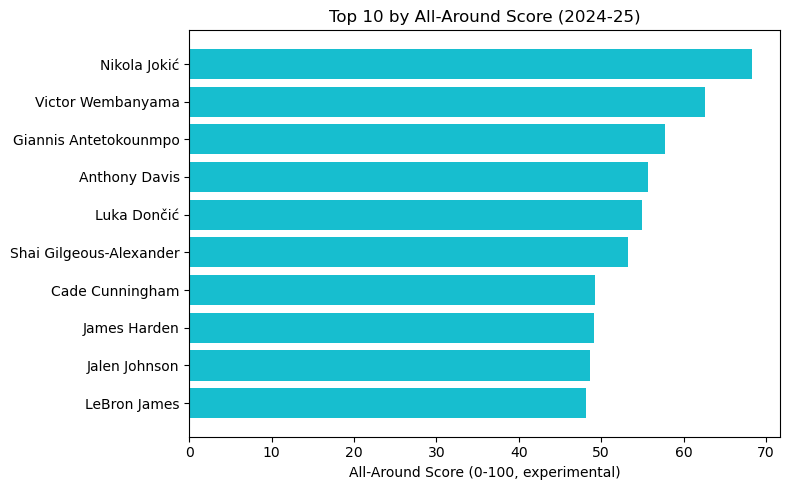

In [21]:
top_all_around = df_clean.sort_values("ALL_AROUND_SCORE", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_all_around["PLAYER"], top_all_around["ALL_AROUND_SCORE"], color="#17becf")
plt.xlabel("All-Around Score (0-100, experimental)")
plt.title("Top 10 by All-Around Score (2024-25)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_all_around_score.png", dpi=150)
plt.show()

**Expected output:** A bar chart of the same top-10 players from the table above.

**How to interpret it:** Compare this chart to the Top 10 Scorers chart from Step 3 -- it's a noticeably different (though overlapping) group of players. That difference is the entire point of building this feature: pure scoring volume and "well-rounded statistical impact" are related but not the same thing.

In [22]:
# Save the dataset with our new engineered features, so later sections
# (archetypes, the player profile function, comparisons) can just load
# this file instead of recalculating everything from scratch.
df_clean.to_csv("../data/nba_player_stats_2024_25_features.csv", index=False)
df_clean.shape

(411, 18)

**Expected output:** `(411, 18)` -- our original 14 columns plus the 3 new per-36 columns and the All-Around Score.

**How to interpret it:** `df_clean` now has everything we need to build player archetypes (Step 5) and the player profile function (Step 6) without repeating any calculations.

## Step 5: Player Archetypes

**What we're doing:** We'll sort every player into one simple, human-readable category -- **Scorer**, **Playmaker**, **Rebounder / Interior Player**, **Two-Way Player**, **All-Around Player**, or **Role Player** -- using plain `if`/`elif` rules based on the stats we already have. This is **not** machine learning: there's no model, no training, no hidden logic. Every rule is a threshold you could check by hand with a calculator.

### How the rules work

**Step A -- define "high" for each stat.** We'll say a player is "high" in a stat if they're in the **top 25%** of our 411-player dataset for that stat (i.e. at or above the 75th percentile). We compute this with `.quantile(0.75)` rather than hardcoding numbers, so the thresholds stay meaningful even if you rerun this notebook on a different season.

**Step B -- apply rules in a fixed order, first match wins:**
1. **All-Around Player** -- "high" in **3 or more** of the 5 categories (PPG, APG, RPG, SPG, BPG). Being well above-average in several categories at once is the clearest sign of a versatile player.
2. **Two-Way Player** -- "high" scoring (PPG) **and** "high" in at least one defensive stat (SPG or BPG). Combines real offensive scoring with real defensive activity.
3. **Scorer** -- "high" PPG only (didn't already qualify above).
4. **Playmaker** -- "high" APG.
5. **Rebounder / Interior Player** -- "high" RPG or BPG (defensive interior presence).
6. **Role Player** -- didn't cross any of the above thresholds. This is a real archetype, not a leftover bucket: most NBA players contribute in modest, valuable ways without leading the league in any single category.

**Why the order matters:** A player could technically qualify for more than one category (e.g. high scoring *and* high rebounding). Checking "All-Around" first means players who are broadly excellent get that label instead of being pigeonholed into just "Scorer." This ordering is a deliberate design choice, not the only valid one.

In [23]:
# "High" = at or above the 75th percentile for that stat, in our own dataset
stat_cols_for_archetype = ["PPG", "APG", "RPG", "SPG", "BPG"]
p75 = {stat: df_clean[stat].quantile(0.75) for stat in stat_cols_for_archetype}
p75

{'PPG': np.float64(14.350000000000001),
 'APG': np.float64(3.4),
 'RPG': np.float64(5.2),
 'SPG': np.float64(1.0),
 'BPG': np.float64(0.6)}

**Expected output:** A dictionary of five numbers, e.g. roughly `PPG: ~14.4`, `APG: ~3.4`, `RPG: ~5.2`, `SPG: ~1.0`, `BPG: ~0.6`. These are simply the actual 75th-percentile values in our cleaned, filtered dataset -- not numbers we made up.

**How to interpret it:** Any player at or above these numbers counts as "high" in that stat for the rules below.

In [24]:
def classify_archetype(row):
    # Count how many of the 5 stats this player is "high" in
    high_count = sum([
        row["PPG"] >= p75["PPG"],
        row["APG"] >= p75["APG"],
        row["RPG"] >= p75["RPG"],
        row["SPG"] >= p75["SPG"],
        row["BPG"] >= p75["BPG"],
    ])

    if high_count >= 3:
        return "All-Around Player"
    if row["PPG"] >= p75["PPG"] and (row["SPG"] >= p75["SPG"] or row["BPG"] >= p75["BPG"]):
        return "Two-Way Player"
    if row["PPG"] >= p75["PPG"]:
        return "Scorer"
    if row["APG"] >= p75["APG"]:
        return "Playmaker"
    if row["RPG"] >= p75["RPG"] or row["BPG"] >= p75["BPG"]:
        return "Rebounder / Interior Player"
    return "Role Player"


# .apply(..., axis=1) runs classify_archetype() once per row (per player)
df_clean["ARCHETYPE"] = df_clean.apply(classify_archetype, axis=1)

df_clean["ARCHETYPE"].value_counts()

ARCHETYPE
Role Player                    198
All-Around Player               82
Rebounder / Interior Player     68
Playmaker                       31
Scorer                          28
Two-Way Player                   4
Name: count, dtype: int64

**What this code does:** `classify_archetype` is a plain Python function -- it takes one player's row and returns one of our six category names, following the priority order described above. `df_clean.apply(classify_archetype, axis=1)` runs that function on every row and stores the result in a new `ARCHETYPE` column.

**Expected output:** A count of players in each category, roughly:
- Role Player: ~198
- All-Around Player: ~82
- Rebounder / Interior Player: ~68
- Playmaker: ~31
- Scorer: ~28
- Two-Way Player: ~4

**How to interpret it:** "Role Player" being the largest group (about half the dataset) matches basketball reality -- most rotation players contribute solidly without leading the league in any specific category. "Two-Way Player" being the smallest group makes sense too: our rule requires *both* high scoring *and* high defensive activity, which is a demanding combination that few players meet.

In [25]:
# Spot-check a few players from each archetype to sanity-check the rules
for archetype, group in df_clean.groupby("ARCHETYPE"):
    print(f"=== {archetype} ({len(group)} players) ===")
    sample = group.sort_values("ALL_AROUND_SCORE", ascending=False).head(3)
    print(sample[["PLAYER", "TEAM", "PPG", "APG", "RPG", "SPG", "BPG"]].to_string(index=False))
    print()

=== All-Around Player (82 players) ===
               PLAYER TEAM  PPG  APG  RPG  SPG  BPG
         Nikola Jokić  DEN 29.6 10.2 12.7  1.8  0.6
    Victor Wembanyama  SAS 24.3  3.7 11.0  1.1  3.8
Giannis Antetokounmpo  MIL 30.4  6.5 11.9  0.9  1.2

=== Playmaker (31 players) ===
           PLAYER TEAM  PPG  APG  RPG  SPG  BPG
Russell Westbrook  DEN 13.3  6.1  4.9  1.4  0.5
    Fred VanVleet  HOU 14.1  5.6  3.7  1.6  0.4
       Chris Paul  SAS  8.8  7.4  3.6  1.3  0.3

=== Rebounder / Interior Player (68 players) ===
        PLAYER TEAM  PPG  APG  RPG  SPG  BPG
Walker Kessler  UTA 11.1  1.7 12.2  0.6  2.4
   Rudy Gobert  MIN 12.0  1.8 10.9  0.8  1.4
   Jalen Duren  DET 11.8  2.7 10.3  0.7  1.1

=== Role Player (198 players) ===
       PLAYER TEAM  PPG  APG  RPG  SPG  BPG
Herbert Jones  NOP 10.3  3.3  3.9  1.9  0.5
Cason Wallace  OKC  8.4  2.5  3.4  1.8  0.5
Naji Marshall  DAL 13.2  3.0  4.8  1.0  0.2

=== Scorer (28 players) ===
       PLAYER TEAM  PPG  APG  RPG  SPG  BPG
 Devin Booker  

**Expected output:** Recognizable, sensible groupings, for example:
- **All-Around Player:** Nikola Jokić, Victor Wembanyama, Giannis Antetokounmpo -- versatile stars who show up near the top of multiple stat categories.
- **Playmaker:** veteran, pass-first guards like Russell Westbrook and Chris Paul -- high assists without elite scoring volume.
- **Rebounder / Interior Player:** centers like Walker Kessler and Rudy Gobert.
- **Scorer:** high-volume shooters like Devin Booker and Jalen Brunson who score a lot without leading in assists or rebounds.
- **Two-Way Player:** wings like Devin Vassell and Jerami Grant who score reasonably well and contribute defensively, but aren't elite enough in either to cross into "All-Around."

**How to interpret it:** This spot-check is important -- it's how we catch a badly-designed rule before trusting it. If we saw, say, a backup center who barely plays labeled "All-Around Player," that would tell us our thresholds or logic need rethinking. Since these results match basketball intuition, we can trust the rules reasonably well.

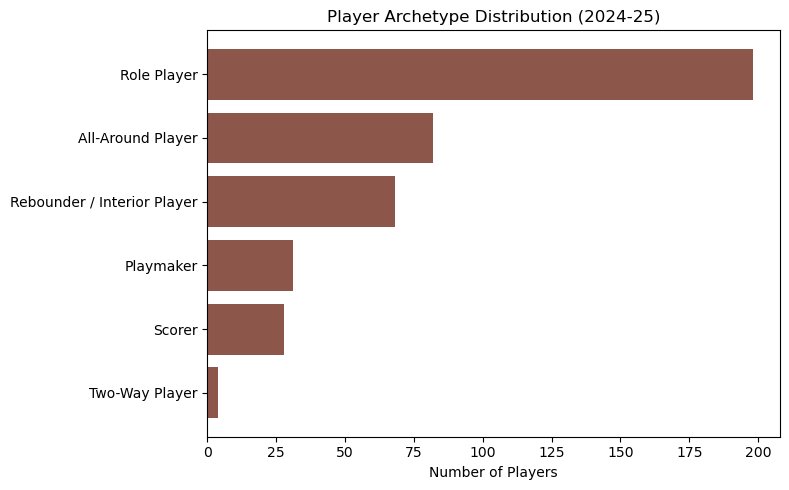

In [26]:
archetype_counts = df_clean["ARCHETYPE"].value_counts()

plt.figure(figsize=(8, 5))
plt.barh(archetype_counts.index, archetype_counts.values, color="#8c564b")
plt.xlabel("Number of Players")
plt.title("Player Archetype Distribution (2024-25)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/charts/archetype_distribution.png", dpi=150)
plt.show()

# Save the dataset with archetypes included for use in later steps
df_clean.to_csv("../data/nba_player_stats_2024_25_features.csv", index=False)

**Expected output:** A horizontal bar chart of the six archetypes and how many players fall into each, saved to `outputs/charts/`. The updated `df_clean` (now including `ARCHETYPE`) overwrites our features CSV so Steps 6-7 can reuse it.

### Limitations of this approach (worth stating honestly)

- **The 75th-percentile cutoff is a judgment call**, not a law of basketball. A different cutoff (say, top 20% or top 30%) would shift some players between categories.
- **Rule order affects the outcome.** A player who's "high" in both PPG and RPG, but not enough categories to hit "All-Around," will land in "Scorer" simply because that rule is checked before "Rebounder / Interior Player" -- not because scoring is objectively their more important skill.
- **No position context.** A 6'2" guard and a 7'0" center with the same rebounding number are treated identically, even though that number means very different things for their position.
- **Single label per player.** Real players are often blends (e.g. a scoring point guard) that a one-category system can't fully capture -- this is exactly the kind of nuance a real machine learning model *could* eventually help with, which is intentionally out of scope for this project.

## Step 6: A `player_profile()` Function

**What we're doing:** Everything so far has worked on the whole dataset at once. Now we'll package what we know about *one* player into a single reusable function -- pass in a name, get back their full statistical profile plus a chart comparing them to the league average. This is the same idea as the individual "player card" you'd see on a stats website, just one we built ourselves.

In [27]:
def player_profile(player_name):
    # str.contains() lets us match "shai" to "Shai Gilgeous-Alexander" --
    # case=False makes it case-insensitive, so capitalization doesn't matter
    matches = df_clean[df_clean["PLAYER"].str.contains(player_name, case=False, na=False)]

    if len(matches) == 0:
        print(f"No player found matching '{player_name}'.")
        return None

    if len(matches) > 1:
        print(f"Multiple players match '{player_name}': {matches['PLAYER'].tolist()}")
        print("Please type more of the name to narrow it down.")
        return None

    player = matches.iloc[0]  # the single matching row

    print(f"===== {player['PLAYER']} =====")
    print(f"Team:      {player['TEAM']}")
    print(f"Position:  {player['POSITION']}")
    print(f"Archetype: {player['ARCHETYPE']}")
    print()
    print(f"PPG {player['PPG']:.1f}   APG {player['APG']:.1f}   RPG {player['RPG']:.1f}   "
          f"SPG {player['SPG']:.1f}   BPG {player['BPG']:.1f}")
    print(f"FG%  {player['FG_PCT']:.1%}   3P%  {player['FG3_PCT']:.1%}   FT%  {player['FT_PCT']:.1%}")
    print()
    print(f"Per 36 minutes -> PTS {player['PTS_per_36']:.1f}, "
          f"AST {player['AST_per_36']:.1f}, REB {player['REB_per_36']:.1f}")
    print()
    print(f"All-Around Score: {player['ALL_AROUND_SCORE']} / 100 (experimental metric, see Step 4)")

    # --- Visual: this player vs. the league average, for 5 key stats ---
    stats = ["PPG", "APG", "RPG", "SPG", "BPG"]
    player_values = [player[s] for s in stats]
    league_avg = [df_clean[s].mean() for s in stats]

    x = range(len(stats))
    width = 0.35
    plt.figure(figsize=(7, 5))
    plt.bar([i - width / 2 for i in x], player_values, width, label=player["PLAYER"])
    plt.bar([i + width / 2 for i in x], league_avg, width, label="League Average*")
    plt.xticks(list(x), stats)
    plt.ylabel("Per Game")
    plt.title(f"{player['PLAYER']} vs. League Average")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return player

**What this code does, piece by piece:**
- `str.contains(player_name, case=False, na=False)` finds any player whose name contains the text you typed, ignoring capitalization -- so `player_profile("shai")` works just as well as the full name.
- If zero or multiple players match, the function prints a helpful message and returns `None` instead of crashing -- this is basic, beginner-friendly error handling, not a fancy try/except block.
- The `print()` block lays out exactly the fields the project calls for: team, position, archetype, the five per-game stats, three shooting percentages, three per-36 stats, and the All-Around Score. `:.1f` and `:.1%` are Python's way of formatting numbers to one decimal place (or as a percentage).
- The chart uses `plt.bar()` twice at slightly shifted x-positions (`-width/2` and `+width/2`) to draw two side-by-side bars per stat -- a standard "grouped bar chart" pattern.
- `*League Average` is calculated from our 411-player cleaned dataset (rotation players only, from Step 2's filter) -- not literally every player who touched an NBA court, which is worth remembering when interpreting the comparison.

**Expected output when you call it:** A short text profile, followed by a bar chart with two bars per stat category -- the player's bar and the league-average bar side by side.

===== Shai Gilgeous-Alexander =====
Team:      OKC
Position:  G
Archetype: All-Around Player

PPG 32.7   APG 6.4   RPG 5.0   SPG 1.7   BPG 1.0
FG%  51.9%   3P%  37.5%   FT%  89.8%

Per 36 minutes -> PTS 34.4, AST 6.7, REB 5.3

All-Around Score: 53.2 / 100 (experimental metric, see Step 4)


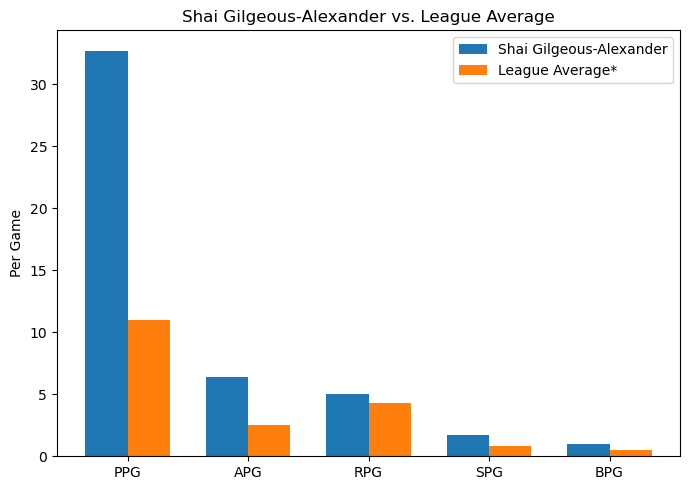

In [28]:
player_profile("Shai Gilgeous-Alexander");

**How to interpret it:** Shai Gilgeous-Alexander should show up with a `Scorer` or `All-Around Player` archetype (he led the league in scoring while contributing across the board) and every one of his bars should tower over the league-average bars -- expected for an MVP-level player. This is also a good sanity check: if the numbers here didn't match what we already saw in Steps 3-5 for this player, that would indicate a bug.

===== Domantas Sabonis =====
Team:      SAC
Position:  F-C
Archetype: All-Around Player

PPG 19.1   APG 6.0   RPG 13.9   SPG 0.7   BPG 0.4
FG%  59.0%   3P%  41.7%   FT%  75.4%

Per 36 minutes -> PTS 19.8, AST 6.2, REB 14.4

All-Around Score: 47.0 / 100 (experimental metric, see Step 4)


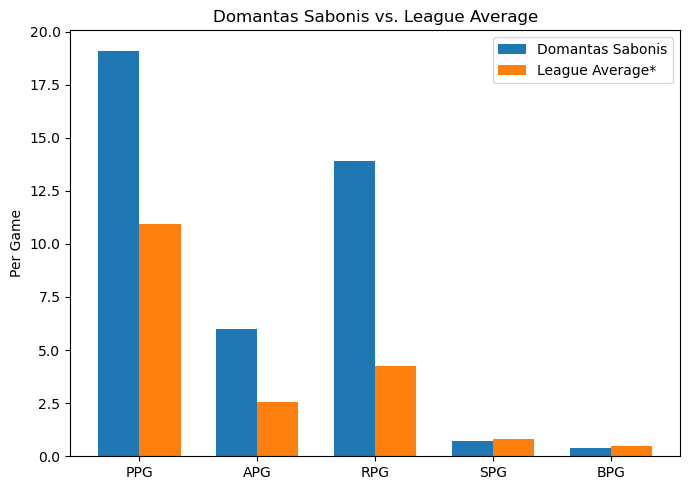

In [29]:
# Try it on another player to confirm the function generalizes, not just for one hardcoded case
player_profile("Domantas Sabonis");

**How to interpret it:** Sabonis actually lands as an **All-Around Player** here too -- not just "Rebounder / Interior Player" -- because his assist numbers (6.0 APG) are unusually high for a big man, on top of elite rebounding (13.9 RPG). This is a good example of the rules working as intended: a player doesn't need to be a guard to qualify as all-around, they just need to be broadly excellent, which Sabonis clearly is. His RPG bar towering over the league average, alongside a well-above-average APG bar, is exactly the kind of two-category (or more) dominance the archetype rule is built to catch.

## Step 7: A `compare_players()` Function

**What we're doing:** `player_profile()` looks at one player at a time. Often the more interesting question is *"how does Player A stack up against Player B?"* -- so we'll build a second function that takes two names and returns a side-by-side comparison table plus a chart.

In [30]:
def compare_players(player_a_name, player_b_name):
    def find_player(name):
        matches = df_clean[df_clean["PLAYER"].str.contains(name, case=False, na=False)]
        if len(matches) == 0:
            print(f"No player found matching '{name}'.")
            return None
        if len(matches) > 1:
            print(f"Multiple players match '{name}': {matches['PLAYER'].tolist()}")
            return None
        return matches.iloc[0]

    player_a = find_player(player_a_name)
    player_b = find_player(player_b_name)
    if player_a is None or player_b is None:
        return None

    compare_cols = [
        "TEAM", "POSITION", "ARCHETYPE",
        "PPG", "APG", "RPG", "SPG", "BPG",
        "FG_PCT", "FG3_PCT", "FT_PCT",
        "PTS_per_36", "AST_per_36", "REB_per_36",
        "ALL_AROUND_SCORE",
    ]

    # Building a DataFrame from two Series (one per player) puts the stat
    # names down the side (the index) and one player per column -- an easy
    # side-by-side layout to read.
    comparison = pd.DataFrame({
        player_a["PLAYER"]: player_a[compare_cols],
        player_b["PLAYER"]: player_b[compare_cols],
    })

    # --- Visual: the two players, side by side, for 5 key stats ---
    stats = ["PPG", "APG", "RPG", "SPG", "BPG"]
    x = range(len(stats))
    width = 0.35
    plt.figure(figsize=(7, 5))
    plt.bar([i - width / 2 for i in x], player_a[stats], width, label=player_a["PLAYER"])
    plt.bar([i + width / 2 for i in x], player_b[stats], width, label=player_b["PLAYER"])
    plt.xticks(list(x), stats)
    plt.ylabel("Per Game")
    plt.title(f"{player_a['PLAYER']} vs. {player_b['PLAYER']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return comparison

**What this code does:**
- `find_player()` is defined *inside* `compare_players()` and used twice -- once per name -- so we don't repeat the same lookup logic twice in a row. It works exactly like the matching step inside `player_profile()` from Step 6.
- `pd.DataFrame({name_a: series_a, name_b: series_b})` is a quick way to combine two players' stats into one readable table, with each player as a column.
- The bar chart follows the same grouped-bar pattern as Step 6, just comparing two named players instead of a player against the league average.

**Expected output:** A table with 15 rows (one per stat) and 2 columns (one per player), plus a grouped bar chart.

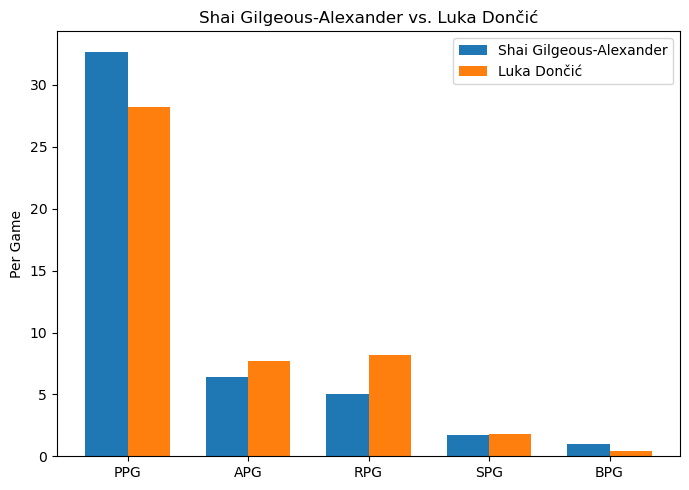

,Shai Gilgeous-Alexander,Luka Dončić
TEAM,OKC,LAL
POSITION,G,F-G
ARCHETYPE,All-Around Player,All-Around Player
PPG,32.7,28.2
APG,6.4,7.7
RPG,5.0,8.2
SPG,1.7,1.8
BPG,1.0,0.4
FG_PCT,0.519,0.45
FG3_PCT,0.375,0.368


In [31]:
# Note: we search for "Luka" rather than typing "Luka Doncic" -- his name
# is stored with accent marks ("Luka Dončić"), and a plain-ASCII typo like
# "Doncic" wouldn't match. Partial names sidestep this -- one more small
# reason the fuzzy `str.contains()` matching from Step 6 is convenient.
compare_players("Shai Gilgeous-Alexander", "Luka")

**How to interpret it:** Both are elite, high-usage scorers, so expect their `PPG` and `ALL_AROUND_SCORE` to be in a similar range. Look for where they actually differ -- for example, one might show a notably higher `APG` or `SPG` than the other. Differences like that are exactly what a comparison function is for: two players can have similar overall value while getting there in different ways.

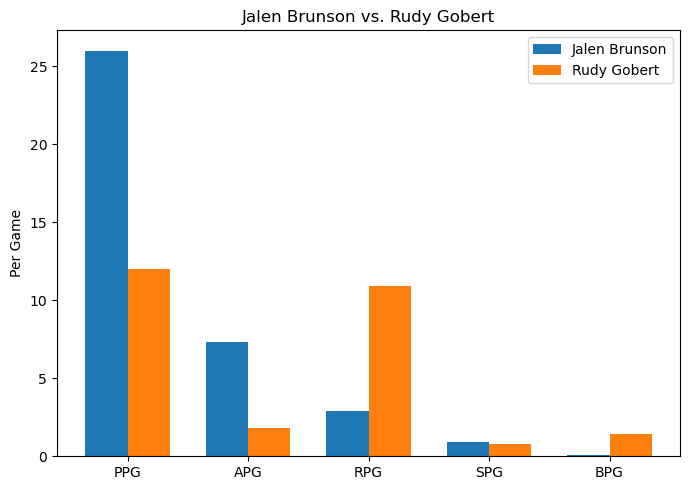

,Jalen Brunson,Rudy Gobert
TEAM,NYK,MIN
POSITION,G,C
ARCHETYPE,Scorer,Rebounder / Interior Player
PPG,26.0,12.0
APG,7.3,1.8
RPG,2.9,10.9
SPG,0.9,0.8
BPG,0.1,1.4
FG_PCT,0.488,0.669
FG3_PCT,0.383,0.0


In [32]:
# Try a very different pairing -- a scorer vs. a rebounder -- to confirm
# the function highlights contrast, not just similarity
compare_players("Jalen Brunson", "Rudy Gobert")

**How to interpret it:** This pairing should show almost the opposite pattern from the first one -- Brunson's `PPG` and `AST_per_36` bars should dominate, while Gobert's `RPG` and `BPG` bars should dominate, and their `ARCHETYPE` values should differ (likely `Scorer`-leaning vs. `Rebounder / Interior Player`). Seeing a sharp, sensible contrast here is a good final confirmation that our stats, per-36 calculations, and archetype rules from earlier steps are all working together consistently.

## Step 8: Insights

**What we're doing:** Pulling together the concrete findings from Steps 3-7 into short, evidence-backed takeaways. Each one follows **Observation -> Evidence -> Interpretation**: what we noticed, the specific number or chart that shows it, and what it plausibly means. Nothing here was decided before looking at the data -- every insight traces back to a cell above.

### 1. Playing time is the single strongest driver of raw production
**Observation:** Players who play more minutes put up bigger per-game numbers almost across the board.
**Evidence:** `MIN` correlates 0.87 with `PPG`, 0.75 with `TOV`, and 0.69 with `APG` (Step 3 correlation heatmap).
**Interpretation:** Raw counting stats are partly a measure of *opportunity*, not just skill. This is exactly why we built per-36-minute stats in Step 4 -- they're needed to compare a bench player fairly against a starter.

### 2. Ball-handling responsibility comes bundled with turnover risk
**Observation:** Players who rack up more assists also commit more turnovers.
**Evidence:** `APG` and `TOV` have the strongest correlation in the entire matrix, at **0.85** (Step 3).
**Interpretation:** A raw turnover count without context is close to meaningless -- a point guard with 8 assists and 3 turnovers is playing far more carefully than a bench player with 1 assist and 1.5 turnovers, even though the second player's turnover *count* looks lower.

### 3. Scoring, playmaking, and rebounding leaderboards are mostly separate groups of players
**Observation:** The Top 10 lists for points, assists, and rebounds (Step 3) share almost no players.
**Evidence:** Of the 30 player-slots across those three leaderboards, only **Nikola Jokić** appears in all three.
**Interpretation:** Statistical specialization is the norm in the NBA -- most stars excel in one or two categories. Showing up near the top of three unrelated leaderboards at once is genuinely rare, which is part of why Jokić also tops the All-Around Score in Step 4.

### 4. Interior defense and rebounding form their own skill cluster, separate from shooting and passing
**Observation:** Rebounding and shot-blocking move together, but neither tracks closely with assists or shooting efficiency.
**Evidence:** `RPG`-`BPG` correlate at **0.65**, while `BPG`-`APG` is essentially **0.01** and `RPG`-`APG` is **0.28** (Step 3 heatmap).
**Interpretation:** "Interior/defensive presence" behaves as a fairly distinct statistical dimension from "perimeter skill" (passing, shooting) -- which is part of why our archetype rules in Step 5 treat `RPG`/`BPG` as one signal (Rebounder/Interior) separate from `APG` (Playmaker).

### 5. Field goal percentage systematically favors centers over 3-point shooters
**Observation:** Our "most efficient high-volume scorers" leaderboard (Step 3) was dominated by centers -- Ivica Zubac, Mark Williams, Evan Mobley, Nikola Vučević -- rather than perimeter players.
**Evidence:** `FG_PCT` and `FG3_PCT` are *negatively* correlated at **-0.48** (Step 3 heatmap) -- players who take a lot of 3s tend to have lower overall `FG_PCT`, even when they're efficient scorers by other measures.
**Interpretation:** A single efficiency stat can quietly encode a bias toward one style of play. This is a genuine limitation of our Step 3 analysis, not just a footnote -- any single-number "efficiency" ranking should be read alongside shot profile, not treated as definitive.

### 6. The All-Around Score surfaces different "best players" than pure scoring totals
**Observation:** Nikola Jokić leads the All-Around Score (68.3 / 100) despite ranking 3rd in the league in scoring among our filtered players, and Victor Wembanyama ranks 2nd overall (62.6) without leading any single category outright.
**Evidence:** Step 4's All-Around Score table and Step 3's Top 10 Scorers list.
**Interpretation:** Combining categories can reveal value that a single leaderboard hides -- Jokić's case makes the argument for the All-Around Score's design, even though (as noted in Step 4) it's an experimental metric that weights all five categories equally.

### 7. Most rotation players are statistically "Role Players" -- true two-way threats are rare
**Observation:** Nearly half our filtered dataset falls into the `Role Player` archetype, while almost none qualify as `Two-Way Player`.
**Evidence:** 198 of 411 players (48%) were classified `Role Player`, versus only 4 (1%) as `Two-Way Player` (Step 5).
**Interpretation:** Under our rules, being simultaneously a high-volume scorer *and* a high-activity defender is one of the rarest statistical combinations in the league -- consistent with why such players (2-way wings) tend to be highly sought after.

### 8. Two players can reach similar overall value through very different statistical paths
**Observation:** Shai Gilgeous-Alexander and Luka Dončić post nearly identical All-Around Scores despite different statistical profiles.
**Evidence:** `compare_players("Shai Gilgeous-Alexander", "Luka")` in Step 7 -- SGA: 53.2 (higher `FG_PCT`, `FT_PCT`, `BPG`); Dončić: 55.0 (higher `APG`, `RPG`).
**Interpretation:** A single overall score should be read together with the underlying stat breakdown, not as a complete ranking on its own -- which is exactly why `player_profile()` and `compare_players()` always show the full stat line, not just the final score.

## Conclusion

This project walked through a full, beginner-friendly data analysis workflow -- loading and understanding data, cleaning it with documented reasoning, exploring it with purposeful charts, engineering a few transparent derived stats, building simple rule-based player archetypes, and packaging everything into two reusable functions (`player_profile()` and `compare_players()`) -- without using any machine learning.

Every number in the "Insights" section above ties back to a specific cell earlier in this notebook, which is intentional: the goal was to practice turning raw data into clearly-reasoned findings, not to produce a polished black-box tool.